In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import vertical_profile as vp
import solvers
import heterostructure_models.dot_2d as d2d 
import heterostructure_models.dot_3d as d3d
import constants

Simulating disordered profiles using the TB and EM solvers

sigma_delta (1D) = 28.47 micro-eV


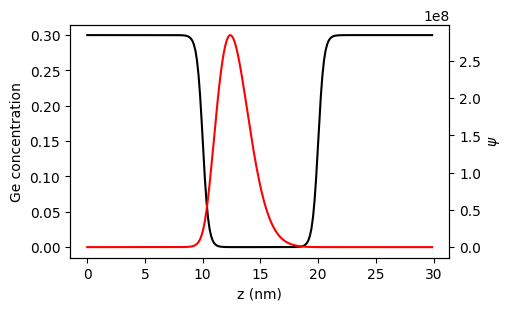

sigma_delta (2D) = 29.97 micro-eV


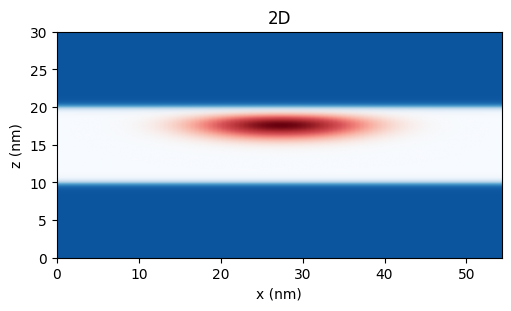

sigma_delta (3D) = 31.39 micro-eV


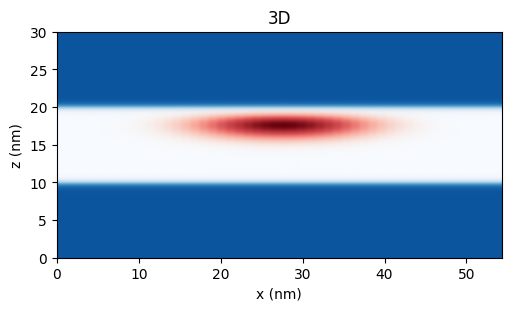

In [4]:
# Create a heterostructure profile
prof = vp.VerticalProfile(interface_type = 'sigmoid')
z_arr = prof.z_arr_nm

# Get a disordered 1D Si concentration array

vertical_field = 0.005 # V/nm
conf_energy = 2e-3

omega = conf_energy * constants.ELEMENTARY_CHARGE / constants.HBAR
a_dot_nm = 1e9 * np.sqrt(constants.HBAR / constants.SI_TRANSVERSE_MASS / omega)


#########
# 1D Calculations
#########

model_em_1D = solvers.EffectiveMass_1D(
    effective_lattice = prof.si_concentrations, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = vertical_field,
    sparse = False
)

sd_1d = model_em_1D.sigma_delta(a_dot_nm, a_dot_nm)
print(f"sigma_delta (1D) = {1e6*sd_1d:0.2f} micro-eV")

_, v0 = model_em_1D.solve(n_lowest_eigenstates=1)
fig, ax = plt.subplots(figsize=(5,3), layout='constrained')
ax2 = ax.twinx()
ax.plot(z_arr, 1-prof.si_concentrations, 'k-', label='Ge concentration')
ax2.plot(z_arr, v0**2, '-', color='r', label='EM ground')
ax.set_xlabel('z (nm)')
ax.set_ylabel('Ge concentration')
ax2.set_ylabel(r'$\psi$')
plt.show()


#########
# 2D Calculations
#########

lat_2d = d2d.Dot2D(si_concentrations = prof.si_concentrations)

model_em_2D = solvers.EffectiveMass_2D(
    dx_nm = lat_2d.dx_nm,
    effective_lattice = lat_2d.effective_lattice, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = vertical_field,
    sparse = True,
    lateral_confinement_energy = conf_energy,
)

sd_2d = model_em_2D.sigma_delta(a_dot_nm)
print(f"sigma_delta (2D) = {1e6*sd_2d:0.2f} micro-eV")

_, v0 = model_em_2D.solve(n_lowest_eigenstates=1)

density_0 = model_em_2D.wf_2D_matrix_from_vector(v0[:,0])
density_0 = density_0**2
alphas_0 = Normalize(clip=True)(density_0)
extent = [0, model_em_2D.nx * model_em_2D.dx_nm, 0, model_em_2D.nz * model_em_2D.dz_nm]

fig, ax = plt.subplots(figsize=(5,3), layout='constrained')
ax.imshow(1-lat_2d.effective_lattice.T, cmap='Blues', vmin=0, vmax=0.35, aspect='auto', extent=extent)
im0 = ax.imshow(density_0.T, alpha=alphas_0.T, cmap="Reds", aspect='auto', extent=extent)
ax.set_title('2D')
ax.set_xlabel('x (nm)')
ax.set_ylabel('z (nm)')
plt.show()

#########
# 3D Calculations
#########

lat_3d = d3d.Dot3D(si_concentrations = prof.si_concentrations, dx_unit_cells=2, dy_unit_cells=2, nx=50, ny=50)

model_em_3D = solvers.EffectiveMass_3D(
    dx_nm = lat_3d.dx_nm,
    dy_nm = lat_3d.dy_nm,
    effective_lattice = lat_3d.effective_lattice, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = vertical_field,
    sparse = True,
    lateral_confinement_energy_x = conf_energy,
    lateral_confinement_energy_y = conf_energy,
)

sd_3d = model_em_3D.sigma_delta()
print(f"sigma_delta (3D) = {1e6*sd_3d:0.2f} micro-eV")

_, v0 = model_em_3D.solve(n_lowest_eigenstates=1)

density_0 = model_em_3D.wf_3D_matrix_from_vector(v0[:,0])
density_0 = density_0**2
density_0 = np.mean(density_0, axis=1) # average along y
alphas_0 = Normalize(clip=True)(density_0)
extent = [0, model_em_3D.nx * model_em_3D.dx_nm, 0, model_em_3D.nz * model_em_3D.dz_nm]

lat_show = np.mean(lat_3d.effective_lattice, axis=1) # average along y
fig, ax = plt.subplots(figsize=(5,3), layout='constrained')
ax.imshow(1-lat_show.T, cmap='Blues', vmin=0, vmax=0.35, aspect='auto', extent=extent)
im0 = ax.imshow(density_0.T, alpha=alphas_0.T, cmap="Reds", aspect='auto', extent=extent)
ax.set_title('3D')
ax.set_xlabel('x (nm)')
ax.set_ylabel('z (nm)')
plt.show()
